# Stochastic Interest Rate Modelling and Prediction

**Model:** Cox-Ingersoll-Ross (CIR)  
**Data:** Historical Bond Yield Time Series (9 maturities)  
**Goal:** Calibrate CIR, reconstruct yield curve from 3M rate only, out-of-sample R² > 0.85

---

## Table of Contents
1. Data Engineering & Preprocessing  
2. CIR Model — Theory & Implementation  
3. Parameter Calibration (MLE / OLS)  
4. Feller Condition Analysis  
5. Yield Curve Reconstruction  
6. Prediction from 3M Rate Only  
7. Evaluation & Backtesting  
8. Advanced Extension  
9. Critical Analysis  
10. Conclusions

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")


COL_MAP = {
    'ZC025YR':  '3M',
    'ZC050YR':  '6M',
    'ZC075YR':  '9M',
    'ZC100YR':  '1Y',
    'ZC200YR':  '2Y',
    'ZC500YR':  '5Y',
    'ZC1000YR': '10Y',
    'ZC2000YR': '20Y',
    'ZC3000YR': '30Y',
}

MATURITY_YEARS = {
    '3M':  0.25,
    '6M':  0.50,
    '9M':  0.75,
    '1Y':  1.00,
    '2Y':  2.00,
    '5Y':  5.00,
    '10Y': 10.0,
    '20Y': 20.0,
    '30Y': 30.0,
}
TRAIN_PATH    = '../data/train_data.csv'
TEST_PATH     = '../data/test_data.csv'
TEST_3M_PATH  = '../data/test_data_3M.csv'

train_raw   = pd.read_csv(TRAIN_PATH)
test_raw    = pd.read_csv(TEST_PATH)
test_3m_raw = pd.read_csv(TEST_3M_PATH)

print(f"train raw shape : {train_raw.shape}")
print(f"test  raw shape : {test_raw.shape}")
print(f"test 3M   shape : {test_3m_raw.shape}")

train raw shape : (1976, 10)
test  raw shape : (495, 6)
test 3M   shape : (495, 2)


In [3]:
def clean_yields(df, col_map=COL_MAP):
    """
    takes raw csv df and returns a clean version:
    - strips col name spaces + renames to readable labels
    - parses date column
    - sorts by date (just in case)
    - handles any remaining NaNs via forward fill then back fill
    """
    df = df.copy()

    # strip leading/trailing spaces from col names
    df.columns = df.columns.str.strip()

    # map raw codes → readable names; only rename cols that exist in this df
    rename = {k.strip(): v for k, v in col_map.items() if k.strip() in df.columns}
    df = df.rename(columns=rename)

    # parse date — some rows might have weird formats so errors='coerce' is safe
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    # drop rows where date parsing failed
    bad_dates = df['Date'].isna().sum()
    if bad_dates > 0:
        print(f"  dropped {bad_dates} rows with unparseable dates")
    df = df.dropna(subset=['Date'])

    # sort chronologically — critical for time-delta calcs later
    df = df.sort_values('Date').reset_index(drop=True)

    # forward fill then back fill for any NaNs in yield cols
    # ffill first bc yield data is autocorrelated — yesterday is best guess
    yield_cols = [c for c in df.columns if c != 'Date']
    df[yield_cols] = df[yield_cols].ffill().bfill()

    return df


train = clean_yields(train_raw)
test  = clean_yields(test_raw)
test_3m = clean_yields(test_3m_raw)

print("train:", train.shape, "| date range:", train['Date'].min().date(), "→", train['Date'].max().date())
print("test :", test.shape,  "| date range:", test['Date'].min().date(),  "→", test['Date'].max().date())
print("\nTrain columns:", train.columns.tolist())
print("Test  columns:", test.columns.tolist())
print("\nAny NaNs left?")
print("train:", train.isnull().sum().sum(), "| test:", test.isnull().sum().sum())

train: (1976, 10) | date range: 2016-05-19 → 2024-04-26
test : (495, 6) | date range: 2024-04-29 → 2026-04-29

Train columns: ['Date', '3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']
Test  columns: ['Date', '3M', '6M', '9M', '1Y', '2Y']

Any NaNs left?
train: 0 | test: 0


In [4]:
def detect_and_clip_outliers(df, z_thresh=4.0):
    """
    flags and clips yield values that are statistically extreme
    using z-score per column. z=4 is conservative — only catches
    real data errors, not just high-vol periods
    """
    df = df.copy()
    yield_cols = [c for c in df.columns if c != 'Date']
    
    outlier_report = {}
    for col in yield_cols:
        z = np.abs(stats.zscore(df[col].dropna()))
        n_outliers = (z > z_thresh).sum()
        outlier_report[col] = n_outliers

        # clip to [mean - 4std, mean + 4std]
        mu, sigma = df[col].mean(), df[col].std()
        df[col] = df[col].clip(lower=mu - z_thresh*sigma,
                               upper=mu + z_thresh*sigma)

    print("Outliers detected (z > 4.0) per maturity:")
    for col, count in outlier_report.items():
        flag = " ← clipped" if count > 0 else ""
        print(f"  {col:>4s}: {count}{flag}")
    
    return df


train = detect_and_clip_outliers(train)
test  = detect_and_clip_outliers(test)

print("\nPost-cleaning train stats (yields as decimals):")
print(train.describe().round(6))

Outliers detected (z > 4.0) per maturity:
    3M: 0
    6M: 0
    9M: 0
    1Y: 0
    2Y: 0
    5Y: 0
   10Y: 0
   20Y: 0
   30Y: 0
Outliers detected (z > 4.0) per maturity:
    3M: 0
    6M: 0
    9M: 0
    1Y: 0
    2Y: 0

Post-cleaning train stats (yields as decimals):
                             Date           3M           6M           9M  \
count                        1976  1976.000000  1976.000000  1976.000000   
mean   2020-05-05 23:02:25.748987     0.016699     0.017885     0.018529   
min           2016-05-19 00:00:00     0.000486     0.000878     0.001054   
25%           2018-05-10 18:00:00     0.004622     0.005190     0.005449   
50%           2020-05-05 12:00:00     0.011912     0.013815     0.015304   
75%           2022-04-29 18:00:00     0.017112     0.019378     0.021077   
max           2024-04-26 00:00:00     0.051962     0.053195     0.054040   
std                           NaN     0.016642     0.016760     0.016650   

                1Y           2Y           

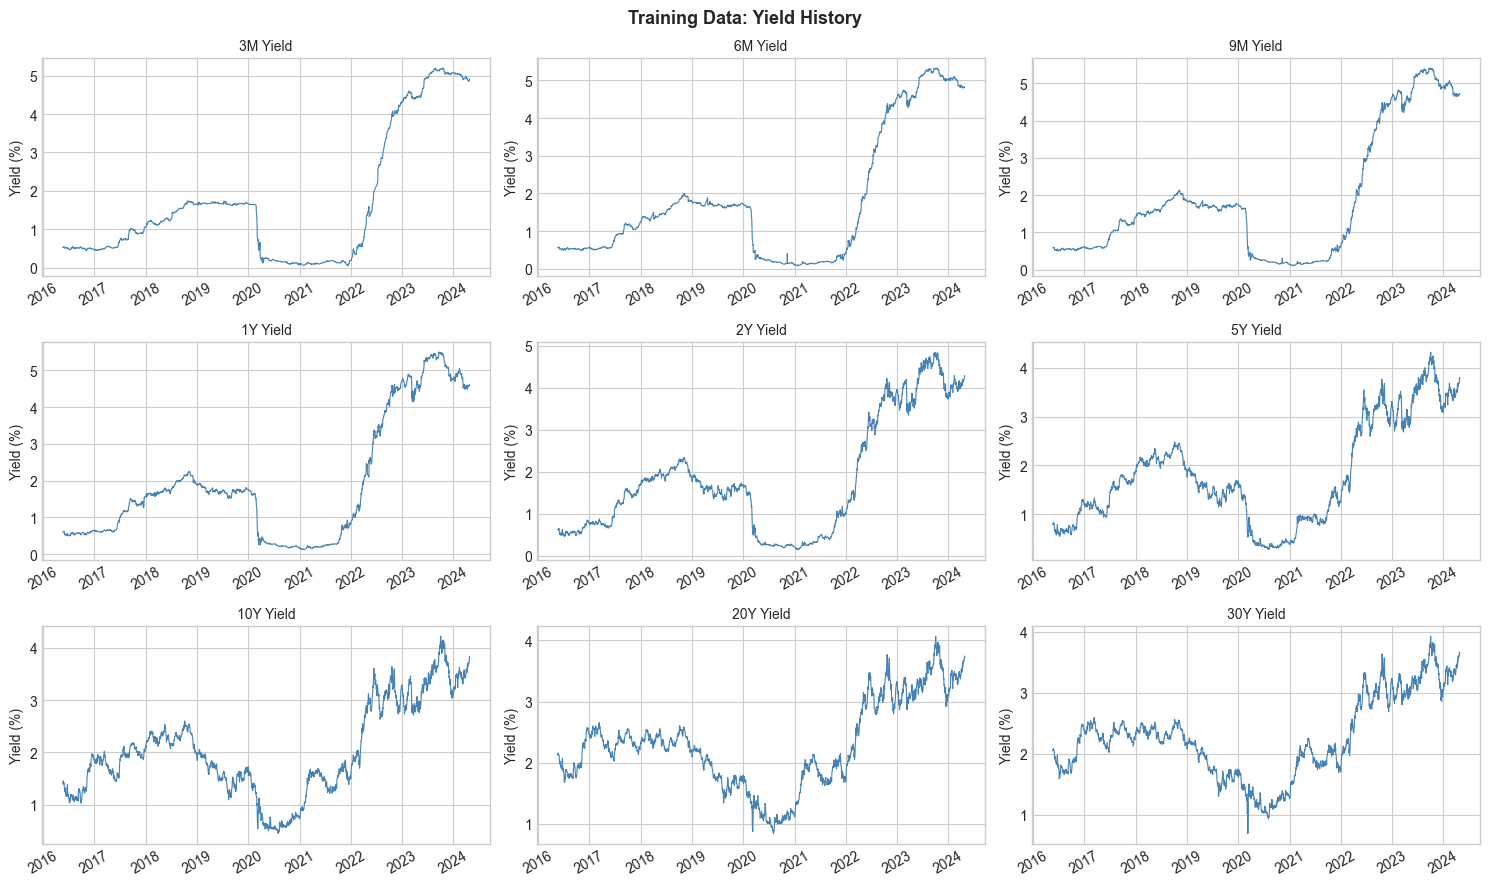

In [5]:
def plot_yield_history(df, title="Training Data: Yield History"):
    """quick look at all maturities over time — useful sanity check"""
    yield_cols = [c for c in df.columns if c != 'Date']
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 9))
    axes = axes.flatten()
    
    for i, col in enumerate(yield_cols):
        axes[i].plot(df['Date'], df[col] * 100, linewidth=0.8, color='steelblue')
        axes[i].set_title(f"{col} Yield", fontsize=10)
        axes[i].set_ylabel("Yield (%)")
        axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        axes[i].tick_params(axis='x', rotation=30)
    
    # hide unused subplots if fewer than 9 cols
    for j in range(len(yield_cols), len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_yield_history(train)

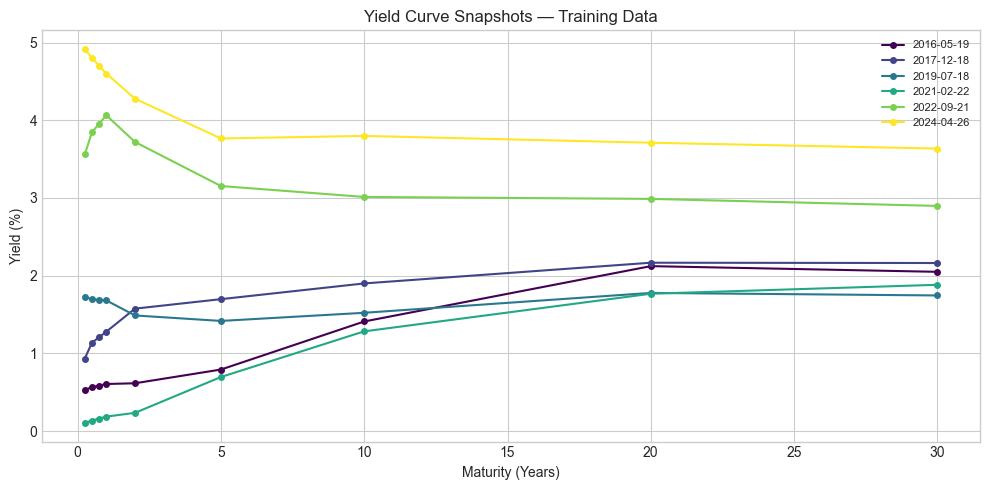

In [6]:
def plot_yield_curve_snapshots(df, n_snapshots=6):
    """
    pick a few evenly spaced dates and plot the yield curve shape
    good way to see if the data looks like a real yield curve
    """
    maturities_in_df = [c for c in df.columns if c != 'Date']
    tenor_years = [MATURITY_YEARS[m] for m in maturities_in_df]
    
    # pick n evenly spaced rows
    idx = np.linspace(0, len(df)-1, n_snapshots, dtype=int)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    cmap = plt.cm.viridis(np.linspace(0, 1, n_snapshots))
    
    for i, row_idx in enumerate(idx):
        row = df.iloc[row_idx]
        yields_pct = [row[m] * 100 for m in maturities_in_df]
        label = str(row['Date'].date())
        ax.plot(tenor_years, yields_pct, marker='o', markersize=4,
                label=label, color=cmap[i], linewidth=1.5)
    
    ax.set_xlabel("Maturity (Years)")
    ax.set_ylabel("Yield (%)")
    ax.set_title("Yield Curve Snapshots — Training Data")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


plot_yield_curve_snapshots(train)
# train only has all 9 maturities — good for this plot